In [ ]:
import duckdb
import pandas as pd
import logging
import requests
import time
import duckdb
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
# Setup logging
logging.basicConfig(
    filename='pipeline.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

# Connect to DuckDB
try:
    con = duckdb.connect('data/imdb_movies.db')
    logging.info('Connected to DuckDB successfully')
except Exception as e:
    logging.error(f'Failed to connect to DuckDB: {e}')
    raise

# Load each IMDb file into pandas then into DuckDB
files = {
    'name_basics':      'data/name.basics.tsv.gz',
    'title_basics':     'data/title.basics.tsv.gz',
    'title_crew':       'data/title.crew.tsv.gz',
    'title_principals': 'data/title.principals.tsv.gz',
    'title_ratings':    'data/title.ratings.tsv.gz',
}

for table_name, filepath in files.items():
    try:
        logging.info(f'Loading {filepath}...')
        df = pd.read_csv(filepath, sep='\t', compression='gzip', low_memory=False, na_values='\\N')
        con.execute(f'DROP TABLE IF EXISTS {table_name}')
        con.execute(f'CREATE TABLE {table_name} AS SELECT * FROM df')
        row_count = con.execute(f'SELECT COUNT(*) FROM {table_name}').fetchone()[0]
        logging.info(f'Loaded {table_name} successfully — {row_count} rows')
        print(f'✓ {table_name}: {row_count:,} rows')
    except Exception as e:
        logging.error(f'Failed to load {table_name}: {e}')
        raise

# Filter title_basics to movies only
try:
    con.execute('''
        CREATE OR REPLACE TABLE movies AS
        SELECT *
        FROM title_basics
        WHERE titleType = 'movie'
    ''')
    movie_count = con.execute('SELECT COUNT(*) FROM movies').fetchone()[0]
    logging.info(f'Created movies table — {movie_count} rows')
    print(f'✓ movies (filtered): {movie_count:,} rows')
except Exception as e:
    logging.error(f'Failed to create movies table: {e}')
    raise

print('\nAll tables loaded successfully into imdb_movies.db')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✓ name_basics: 15,182,692 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✓ title_basics: 12,376,284 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✓ title_crew: 12,380,743 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✓ title_principals: 98,523,875 rows
✓ title_ratings: 1,650,900 rows
✓ movies (filtered): 741,038 rows

All tables loaded successfully into imdb_movies.db


In [ ]:
# Only kept in to maintain reproducibility of TMDB data
API_KEY = '1867e8b00ca347a64e123634955aa0a4'

# Connect to existing DuckDB database
try:
    con = duckdb.connect('data/imdb_movies.db')
    logging.info('Connected to DuckDB for TMDB data load')
except Exception as e:
    logging.error(f'Failed to connect to DuckDB: {e}')
    raise

# Get only movies with at least 5000 votes
try:
    movie_ids = con.execute('''
        SELECT m.tconst 
        FROM movies m
        JOIN title_ratings r ON m.tconst = r.tconst
        WHERE CAST(r.numVotes AS INTEGER) >= 5000
    ''').df()['tconst'].tolist()
    logging.info(f'Fetching TMDB data for {len(movie_ids)} movies')
    print(f'Fetching TMDB data for {len(movie_ids):,} movies...')
except Exception as e:
    logging.error(f'Failed to fetch movie IDs: {e}')
    raise

# Fetch revenue and budget data from TMDB for each movie
results = []

for i, imdb_id in enumerate(movie_ids):
    try:
        # Step 1: Find TMDB ID using IMDb ID
        find_url = f'https://api.themoviedb.org/3/find/{imdb_id}'
        find_response = requests.get(find_url, params={
            'api_key': API_KEY,
            'external_source': 'imdb_id'
        })
        find_data = find_response.json()

        if not find_data.get('movie_results'):
            continue

        tmdb_id = find_data['movie_results'][0]['id']

        # Step 2: Get full movie details including revenue and budget
        details_url = f'https://api.themoviedb.org/3/movie/{tmdb_id}'
        details_response = requests.get(details_url, params={'api_key': API_KEY})
        details = details_response.json()

        results.append({
            'imdb_id':           imdb_id,
            'tmdb_id':           tmdb_id,
            'title':             details.get('title'),
            'revenue':           details.get('revenue'),
            'budget':            details.get('budget'),
            'popularity':        details.get('popularity'),
            'release_date':      details.get('release_date'),
            'original_language': details.get('original_language'),
        })

        # Log progress every 100 movies
        if (i + 1) % 100 == 0:
            logging.info(f'Fetched {i + 1} / {len(movie_ids)} movies')
            print(f'  Progress: {i + 1:,} / {len(movie_ids):,}')

        # Rate limit — TMDB allows 40 requests/second, sleep to be safe
        time.sleep(0.05)

    except Exception as e:
        logging.warning(f'Failed to fetch TMDB data for {imdb_id}: {e}')
        continue

# Convert results to DataFrame
tmdb_df = pd.DataFrame(results)

# Filter out rows where revenue is 0 or missing (TMDB returns 0 for unknown)
tmdb_df = tmdb_df[tmdb_df['revenue'] > 0]

logging.info(f'TMDB fetch complete — {len(tmdb_df)} movies with revenue data')
print(f'\n✓ TMDB fetch complete: {len(tmdb_df):,} movies with revenue data')

# Load into DuckDB
try:
    con.execute('DROP TABLE IF EXISTS tmdb_movies')
    con.execute('CREATE TABLE tmdb_movies AS SELECT * FROM tmdb_df')
    logging.info('tmdb_movies table created in DuckDB')
    print('✓ tmdb_movies loaded into DuckDB')
except Exception as e:
    logging.error(f'Failed to load tmdb_movies into DuckDB: {e}')
    raise

con.close()

Fetching TMDB data for 18,681 movies...
  Progress: 100 / 18,681
  Progress: 200 / 18,681
  Progress: 300 / 18,681
  Progress: 400 / 18,681
  Progress: 500 / 18,681
  Progress: 600 / 18,681
  Progress: 700 / 18,681
  Progress: 800 / 18,681
  Progress: 900 / 18,681
  Progress: 1,000 / 18,681
  Progress: 1,100 / 18,681
  Progress: 1,200 / 18,681
  Progress: 1,300 / 18,681
  Progress: 1,400 / 18,681
  Progress: 1,500 / 18,681
  Progress: 1,600 / 18,681
  Progress: 1,700 / 18,681
  Progress: 1,800 / 18,681
  Progress: 1,900 / 18,681
  Progress: 2,000 / 18,681
  Progress: 2,100 / 18,681
  Progress: 2,200 / 18,681
  Progress: 2,300 / 18,681
  Progress: 2,400 / 18,681
  Progress: 2,500 / 18,681
  Progress: 2,600 / 18,681
  Progress: 2,700 / 18,681
  Progress: 2,800 / 18,681
  Progress: 2,900 / 18,681
  Progress: 3,000 / 18,681
  Progress: 3,100 / 18,681
  Progress: 3,200 / 18,681
  Progress: 3,300 / 18,681
  Progress: 3,400 / 18,681
  Progress: 3,500 / 18,681
  Progress: 3,600 / 18,681
  Prog

In [9]:
# Create a base set of tconsts — only movies with 5000+ votes AND revenue data from TMDB
con.execute('''
    CREATE OR REPLACE TABLE final_movies AS
    SELECT m.*
    FROM movies m
    JOIN title_ratings r ON m.tconst = r.tconst
    JOIN tmdb_movies t ON m.tconst = t.imdb_id
    WHERE CAST(r.numVotes AS INTEGER) >= 5000
    AND t.revenue > 0
''')

# Filter all other tables to only those tconsts
con.execute('''
    CREATE OR REPLACE TABLE final_ratings AS
    SELECT r.* FROM title_ratings r
    WHERE r.tconst IN (SELECT tconst FROM final_movies)
''')

con.execute('''
    CREATE OR REPLACE TABLE final_crew AS
    SELECT c.* FROM title_crew c
    WHERE c.tconst IN (SELECT tconst FROM final_movies)
''')

con.execute('''
    CREATE OR REPLACE TABLE final_principals AS
    SELECT p.* FROM title_principals p
    WHERE p.tconst IN (SELECT tconst FROM final_movies)
''')

# Filter name_basics to only people in final_principals
con.execute('''
    CREATE OR REPLACE TABLE final_names AS
    SELECT n.* FROM name_basics n
    WHERE n.nconst IN (SELECT nconst FROM final_principals)
''')

# Check new row counts
tables = ['final_movies', 'final_ratings', 'final_crew', 'final_principals', 'final_names', 'tmdb_movies']
for table in tables:
    count = con.execute(f'SELECT COUNT(*) FROM {table}').fetchone()[0]
    print(f'{table}: {count:,} rows')

final_movies: 11,552 rows
final_ratings: 11,552 rows
final_crew: 11,552 rows
final_principals: 247,905 rows
final_names: 88,457 rows
tmdb_movies: 11,552 rows


In [9]:
# check total movies in final movies after filtering of 5000+ votes and TMDB revenue data
final_movie_count = con.execute('SELECT COUNT(*) FROM final_movies').fetchone()[0]
logging.info(f'Final movies count after filtering: {final_movie_count}')
print(f'\nFinal movies count after filtering: {final_movie_count:,} movies')


Final movies count after filtering: 11,552 movies


In [ ]:
tables_to_export = ['final_movies', 'final_ratings', 'final_crew', 'final_principals', 'final_names', 'tmdb_movies']

for table in tables_to_export:
    con.execute(f"COPY {table} TO 'data/{table}.parquet' (FORMAT PARQUET)")
    print(f'✓ Exported {table}.parquet')

✓ Exported final_movies.parquet
✓ Exported final_ratings.parquet
✓ Exported final_crew.parquet
✓ Exported final_principals.parquet
✓ Exported final_names.parquet
✓ Exported tmdb_movies.parquet


In [11]:
tables_to_export = ['final_movies', 'final_ratings', 'final_crew', 'final_principals', 'final_names', 'tmdb_movies']

for table in tables_to_export:
    con.execute(f"COPY {table} TO 'data/{table}.csv' (FORMAT CSV)")
    print(f'✓ Exported {table}.csv')

✓ Exported final_movies.csv
✓ Exported final_ratings.csv
✓ Exported final_crew.csv
✓ Exported final_principals.csv
✓ Exported final_names.csv
✓ Exported tmdb_movies.csv


In [12]:
# title_ratings numerical features
print("=== title_ratings ===")
print(con.execute('''
    SELECT 
        ROUND(MIN(CAST(averageRating AS FLOAT)), 2) as min_rating,
        ROUND(MAX(CAST(averageRating AS FLOAT)), 2) as max_rating,
        ROUND(AVG(CAST(averageRating AS FLOAT)), 2) as mean_rating,
        ROUND(STDDEV(CAST(averageRating AS FLOAT)), 2) as std_rating,
        COUNT(*) - COUNT(averageRating) as missing_rating,
        MIN(CAST(numVotes AS INTEGER)) as min_votes,
        MAX(CAST(numVotes AS INTEGER)) as max_votes,
        ROUND(AVG(CAST(numVotes AS FLOAT)), 2) as mean_votes,
        ROUND(STDDEV(CAST(numVotes AS FLOAT)), 2) as std_votes,
        COUNT(*) - COUNT(numVotes) as missing_votes
    FROM final_ratings
''').df().to_string())

# final_movies numerical features
print("\n=== final_movies ===")
print(con.execute('''
    SELECT
        MIN(TRY_CAST(startYear AS INTEGER)) as min_year,
        MAX(TRY_CAST(startYear AS INTEGER)) as max_year,
        ROUND(AVG(TRY_CAST(startYear AS FLOAT)), 2) as mean_year,
        ROUND(STDDEV(TRY_CAST(startYear AS FLOAT)), 2) as std_year,
        COUNT(*) - COUNT(TRY_CAST(startYear AS INTEGER)) as missing_year,
        MIN(TRY_CAST(runtimeMinutes AS INTEGER)) as min_runtime,
        MAX(TRY_CAST(runtimeMinutes AS INTEGER)) as max_runtime,
        ROUND(AVG(TRY_CAST(runtimeMinutes AS FLOAT)), 2) as mean_runtime,
        ROUND(STDDEV(TRY_CAST(runtimeMinutes AS FLOAT)), 2) as std_runtime,
        COUNT(*) - COUNT(TRY_CAST(runtimeMinutes AS INTEGER)) as missing_runtime
    FROM final_movies
''').df().to_string())

# tmdb_movies numerical features
print("\n=== tmdb_movies ===")
print(con.execute('''
    SELECT
        MIN(revenue) as min_revenue,
        MAX(revenue) as max_revenue,
        ROUND(AVG(revenue), 2) as mean_revenue,
        ROUND(STDDEV(revenue), 2) as std_revenue,
        COUNT(*) - COUNT(revenue) as missing_revenue,
        MIN(budget) as min_budget,
        MAX(budget) as max_budget,
        ROUND(AVG(budget), 2) as mean_budget,
        ROUND(STDDEV(budget), 2) as std_budget,
        COUNT(*) - COUNT(budget) as missing_budget,
        ROUND(MIN(popularity), 2) as min_popularity,
        ROUND(MAX(popularity), 2) as max_popularity,
        ROUND(AVG(popularity), 2) as mean_popularity,
        ROUND(STDDEV(popularity), 2) as std_popularity,
        COUNT(*) - COUNT(popularity) as missing_popularity
    FROM tmdb_movies
''').df().to_string())

=== title_ratings ===
   min_rating  max_rating  mean_rating  std_rating  missing_rating  min_votes  max_votes  mean_votes  std_votes  missing_votes
0         1.3         9.3         6.51        0.99               0       5006    3169184    90657.65  183550.86              0

=== final_movies ===
   min_year  max_year  mean_year  std_year  missing_year  min_runtime  max_runtime  mean_runtime  std_runtime  missing_runtime
0      1915      2026    2002.78     17.65             0           43          566        109.62         22.0                0

=== tmdb_movies ===
   min_revenue  max_revenue  mean_revenue   std_revenue  missing_revenue  min_budget  max_budget  mean_budget   std_budget  missing_budget  min_popularity  max_popularity  mean_popularity  std_popularity  missing_popularity
0            1   2923706026   64527437.42  1.535492e+08                0           0   489900000  22398748.18  38003194.16               0             0.0          309.56             3.87            8.38

In [ ]:
# Load final dataset into pandas for modeling
try:
    con = duckdb.connect('data/imdb_movies.db')
    
    df = con.execute("""
        SELECT 
            m.tconst,
            m.primaryTitle,
            m.genres,
            m.runtimeMinutes,
            m.startYear,
            r.averageRating,
            t.budget,
            t.revenue,
            t.original_language
        FROM final_movies m
        JOIN final_ratings r ON m.tconst = r.tconst
        JOIN tmdb_movies t ON m.tconst = t.imdb_id
        WHERE t.revenue > 0
        AND t.budget > 0
    """).df()

    # Replace \N with NaN and cast to numeric in pandas
    df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'], errors='coerce')
    df['startYear'] = pd.to_numeric(df['startYear'], errors='coerce')
    df['averageRating'] = pd.to_numeric(df['averageRating'], errors='coerce')
    df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
    df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

    df = df.dropna(subset=['runtimeMinutes', 'startYear', 'averageRating', 'budget', 'revenue'])

    logging.info(f'Loaded dataset with {len(df)} rows')
    print(f'✓ Loaded {len(df):,} movies')
except Exception as e:
    logging.error(f'Failed to load dataset: {e}')
    raise

# Feature Engineering: create genre dummies, English language flag, and log-transform revenue
try:
    df['genres_list'] = df['genres'].str.split(',')
    mlb = MultiLabelBinarizer()
    genre_dummies = pd.DataFrame(
        mlb.fit_transform(df['genres_list']),
        columns=[f'genre_{g}' for g in mlb.classes_],
        index=df.index
    )
    # Create English language flag
    df['is_english'] = (df['original_language'] == 'en').astype(int)
    # Combine features
    feature_cols = ['runtimeMinutes', 'startYear', 'averageRating', 'budget', 'is_english']
    X = pd.concat([df[feature_cols], genre_dummies], axis=1)
    # Log-transform revenue to reduce skew
    y = np.log1p(df['revenue'])

    # Log feature matrix shape
    logging.info(f'Feature matrix shape: {X.shape}')
    print(f'✓ Features: {X.shape[1]} columns')
except Exception as e:
    logging.error(f'Feature engineering failed: {e}')
    raise

# Train/Validation/Test Split
# Split: 60% train, 20% validation, 20% test
try:
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.4, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )
    # Log dataset sizes
    logging.info(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')
    print(f'✓ Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')
except Exception as e:
    logging.error(f'Train/val/test split failed: {e}')
    raise

# Cross-validation of multiple models
try:
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge':             Ridge(alpha=1.0),
        'Lasso':             Lasso(alpha=0.1),
        'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    }

    # Log and display cross-validation results
    print('\n── Cross Validation Results (5-fold, R²) ──')
    cv_results = {}
    for name, model in models.items():
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
        cv_results[name] = scores
        logging.info(f'{name} CV R²: {scores.mean():.3f} ± {scores.std():.3f}')
        print(f'  {name:25s} R²: {scores.mean():.3f} ± {scores.std():.3f}')
except Exception as e:
    logging.error(f'Cross validation failed: {e}')
    raise

# Hyperparameter Tuning on best models
try:
    # Hyperparameter tuning for Random Forest
    print('\n── Hyperparameter Tuning: Random Forest ──')
    rf_params = {
        'n_estimators': [50, 100, 200],
        'max_depth':    [None, 10, 20],
        'min_samples_split': [2, 5]
    }

    # Use GridSearchCV to find best hyperparameters for Random Forest
    rf_grid = GridSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        rf_params, cv=5, scoring='r2', n_jobs=-1, verbose=1
    )
    rf_grid.fit(X_train, y_train)
    best_rf = rf_grid.best_estimator_
    logging.info(f'Best RF params: {rf_grid.best_params_}')
    print(f'  Best params: {rf_grid.best_params_}')
    print(f'  Best CV R²:  {rf_grid.best_score_:.3f}')

    # Hyperparameter tuning for Gradient Boosting
    print('\n── Hyperparameter Tuning: Gradient Boosting ──')
    gb_params = {
        'n_estimators':  [50, 100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth':     [3, 5]
    }
    
    # Use GridSearchCV to find best hyperparameters for Gradient Boosting
    gb_grid = GridSearchCV(
        GradientBoostingRegressor(random_state=42),
        gb_params, cv=5, scoring='r2', n_jobs=-1, verbose=1
    )
    gb_grid.fit(X_train, y_train)
    best_gb = gb_grid.best_estimator_
    logging.info(f'Best GB params: {gb_grid.best_params_}')
    print(f'  Best params: {gb_grid.best_params_}')
    print(f'  Best CV R²:  {gb_grid.best_score_:.3f}')
except Exception as e:
    logging.error(f'Hyperparameter tuning failed: {e}')
    raise

# Validate best models on validation set
try:
    print('\n── Validation Set Results ──')
    for name, model in [('Random Forest', best_rf), ('Gradient Boosting', best_gb)]:
        model.fit(X_train, y_train)
        y_pred_val = model.predict(X_val)
        val_r2   = r2_score(y_val, y_pred_val)
        val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
        logging.info(f'{name} Val — R²: {val_r2:.3f}, RMSE: {val_rmse:.3f}')
        print(f'  {name:25s} R²: {val_r2:.3f} | RMSE: {val_rmse:.3f}')
except Exception as e:
    logging.error(f'Validation failed: {e}')
    raise

# Final evaluation on test set with best model
try:
    print('\n── Final Test Set Results ──')

    # Picks the model with better validation R² for final test evaluation
    final_model = best_rf if r2_score(y_val, best_rf.predict(X_val)) >= r2_score(y_val, best_gb.predict(X_val)) else best_gb
    final_name  = 'Random Forest' if final_model == best_rf else 'Gradient Boosting'

    y_pred_test = final_model.predict(X_test)
    test_r2   = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # Log and display final test results
    logging.info(f'Final model: {final_name} — Test R²: {test_r2:.3f}, RMSE: {test_rmse:.3f}')
    print(f'  Final model: {final_name}')
    print(f'  Test R²:     {test_r2:.3f}')
    print(f'  Test RMSE:   {test_rmse:.3f}')
except Exception as e:
    logging.error(f'Final test evaluation failed: {e}')
    raise

# Feature Importance
try:
    # Figure out which features were most important in the final model
    importance_df = pd.DataFrame({
        'feature':    X.columns,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False).head(10)

    logging.info('Feature importance calculated successfully')
    print(f'\nTop 10 most important features:')
    print(importance_df.to_string(index=False))
except Exception as e:
    logging.error(f'Feature importance failed: {e}')
    raise

✓ Loaded 8,999 movies
✓ Features: 29 columns
✓ Train: 5,399 | Val: 1,800 | Test: 1,800

── Cross Validation Results (5-fold, R²) ──
  Linear Regression         R²: 0.344 ± 0.011


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.67777e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.01173e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.48106e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.46381e-19): result may not be acc

  Ridge                     R²: 0.345 ± 0.011
  Lasso                     R²: 0.305 ± 0.005
  Random Forest             R²: 0.478 ± 0.022
  Gradient Boosting         R²: 0.498 ± 0.014

── Hyperparameter Tuning: Random Forest ──
Fitting 5 folds for each of 18 candidates, totalling 90 fits
  Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
  Best CV R²:  0.490

── Hyperparameter Tuning: Gradient Boosting ──
Fitting 5 folds for each of 18 candidates, totalling 90 fits
  Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  Best CV R²:  0.501

── Validation Set Results ──
  Random Forest             R²: 0.522 | RMSE: 1.501
  Gradient Boosting         R²: 0.538 | RMSE: 1.475

── Final Test Set Results ──
  Final model: Gradient Boosting
  Test R²:     0.468
  Test RMSE:   1.597

Top 10 most important features:
       feature  importance
        budget    0.726664
 averageRating    0.096136
     startYear    0.053586
runtimeMinutes    0.037035


## **Analysis Rationale**

Several key decisions were made during the analysis process. First, revenue was log-transformed using np.log1p() before modeling because raw revenue values are heavily right-skewed meaning a small number of blockbusters substantially outperform the average film. The log transformation compresses this skew and allows the model to learn more stable relationships across the entire range of films.

Second, genres were one-hot encoded using MultiLabelBinarizer because a film can belong to multiple genres simultaneously, and binary encoding preserves that structure without implying any ordering.

Third, five models were evaluated using 5-fold cross validation before hyperparameter tuning to get an unbiased comparison across model types before committing to the more expensive tuning step.

Fourth, a 60/20/20 train/validation/test split was used rather than a simple 80/20 split. The separate validation set allowed hyperparameter tuning without leaking test set information into model selection, and the final model was chosen based on validation R² before being evaluated once on the held-out test set.

Finally, the best performing model was selected automatically by comparing validation R² scores, and feature importance was extracted to identify which variables contributed most to predicting box office revenue.

The results tell a clean story:

* Budget is by far the most important predictor at 73% — studios that spend more make more
* Rating, release year, and runtime all contribute but are secondary
* Genre matters slightly. Drama, Horror, Crime, Action all show up
* English language films have a small but consistent advantage

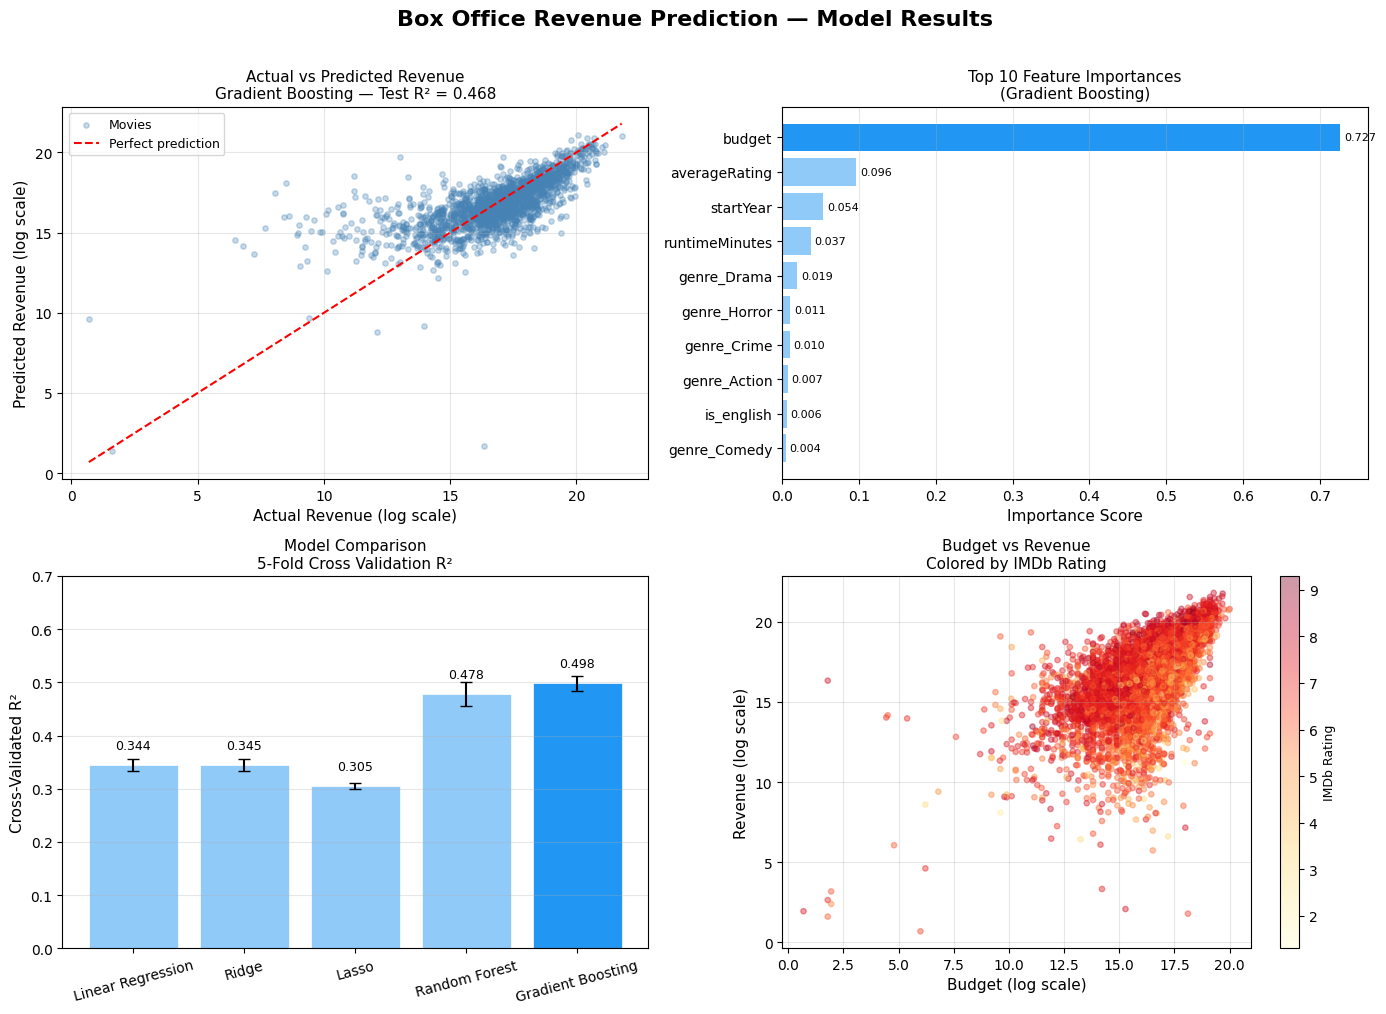

✓ Visualization saved


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Box Office Revenue Prediction — Model Results', fontsize=16, fontweight='bold', y=1.01)

# Actual vs predicted plot of final model on test set
ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred_test, alpha=0.3, color='steelblue', s=15, label='Movies')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=1.5, label='Perfect prediction')
ax1.set_xlabel('Actual Revenue (log scale)', fontsize=11)
ax1.set_ylabel('Predicted Revenue (log scale)', fontsize=11)
ax1.set_title(f'Actual vs Predicted Revenue\nGradient Boosting — Test R² = {test_r2:.3f}', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Feature importance bar chart
ax2 = axes[0, 1]
colors = ['#2196F3' if i == 0 else '#90CAF9' for i in range(len(importance_df))]
bars = ax2.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color=colors[::-1])
ax2.set_xlabel('Importance Score', fontsize=11)
ax2.set_title('Top 10 Feature Importances\n(Gradient Boosting)', fontsize=11)
ax2.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, importance_df['importance'][::-1]):
    ax2.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8)

# Model comparison bar chart of cross-validated R²
ax3 = axes[1, 0]
model_names = list(cv_results.keys())
means = [cv_results[m].mean() for m in model_names]
stds  = [cv_results[m].std() for m in model_names]
bar_colors = ['#90CAF9', '#90CAF9', '#90CAF9', '#90CAF9', '#2196F3']
bars3 = ax3.bar(model_names, means, yerr=stds, capsize=4, 
                color=bar_colors, edgecolor='white', linewidth=0.5)
ax3.set_ylabel('Cross-Validated R²', fontsize=11)
ax3.set_title('Model Comparison\n5-Fold Cross Validation R²', fontsize=11)
ax3.set_ylim(0, 0.7)
ax3.tick_params(axis='x', rotation=15)
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, means):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
             f'{val:.3f}', ha='center', fontsize=9)

# Budget vs Revenue scatter plot colored by IMDb rating
ax4 = axes[1, 1]
scatter = ax4.scatter(
    np.log1p(df['budget']),
    np.log1p(df['revenue']),
    c=df['averageRating'],
    cmap='YlOrRd',
    alpha=0.4,
    s=15
)
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('IMDb Rating', fontsize=9)
ax4.set_xlabel('Budget (log scale)', fontsize=11)
ax4.set_ylabel('Revenue (log scale)', fontsize=11)
ax4.set_title('Budget vs Revenue\nColored by IMDb Rating', fontsize=11)
ax4.grid(True, alpha=0.3)

# Show plots and save figure
plt.tight_layout()
plt.savefig('results/revenue_prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()
logging.info('Visualization saved to results/revenue_prediction_results.png')
print('✓ Visualization saved')

## **Visualization Rationale**

Four visualizations were created to communicate the results of the revenue prediction analysis, each chosen to address a specific aspect of the modeling process.

1. The Actual vs Predicted scatter plot was chosen to give an honest assessment of model performance on the test set. Points close to the red dashed line indicate accurate predictions. The spread around the line visually confirms the R² of 0.468. The model captures the general trend well but has meaningful variance, particularly for lower-revenue films.

2. The Feature Importance bar chart was chosen to directly answer the project's core question — which film characteristics are most associated with revenue. Budget dominates at 0.727, followed by IMDb rating, release year, and runtime. Genre effects are present but small. This chart is the most actionable result for a film studio making production decisions.

3. The Model Comparison bar chart with error bars was chosen to justify the selection of Gradient Boosting as the final model. Showing all five models side by side with cross-validated R² and standard deviation bars makes the comparison transparent and reproducible. Gradient Boosting outperforms all other models with low variance across folds.

4. The Budget vs Revenue scatter plot colored by IMDb rating was chosen to visualize the raw relationship between the two most important variables in the dataset. The strong positive correlation between budget and revenue is immediately visible, and the color encoding reveals that higher-rated films (darker red) tend to cluster toward higher revenue, supporting the feature importance findings.